# Part 1: Exploratory Data Analysis & Hypothesis Testing

## Load and inspect the dataset 

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("D:\\DS602_202618011\\insurance.csv")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Dataset Shape:
(1338, 7)

Data Types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## Descriptive Statistics

In [2]:
# Numerical columns
numerical_columns = ["age", "bmi", "children", "charges"]

# Descriptive statistics
summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Std Dev": df[numerical_columns].std(),
    "IQR": df[numerical_columns].quantile(0.75) - df[numerical_columns].quantile(0.25),
    "Skewness": df[numerical_columns].skew(),
    "Kurtosis": df[numerical_columns].kurtosis()
})

print(summary)

                  Mean    Median       Std Dev           IQR  Skewness  \
age          39.207025    39.000     14.049960     24.000000  0.055673   
bmi          30.663397    30.400      6.098187      8.397500  0.284047   
children      1.094918     1.000      1.205493      2.000000  0.938380   
charges   13270.422265  9382.033  12110.011237  11899.625365  1.515880   

          Kurtosis  
age      -1.245088  
bmi      -0.050732  
children  0.202454  
charges   1.606299  


## Check categorical variables

In [3]:
numerical_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="str").columns

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

# Category counts
for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())

Numerical columns:
Index(['age', 'bmi', 'children', 'charges'], dtype='str')

Categorical columns:
Index(['sex', 'smoker', 'region'], dtype='str')

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


# Distribution Plots

## Histogram/KDE

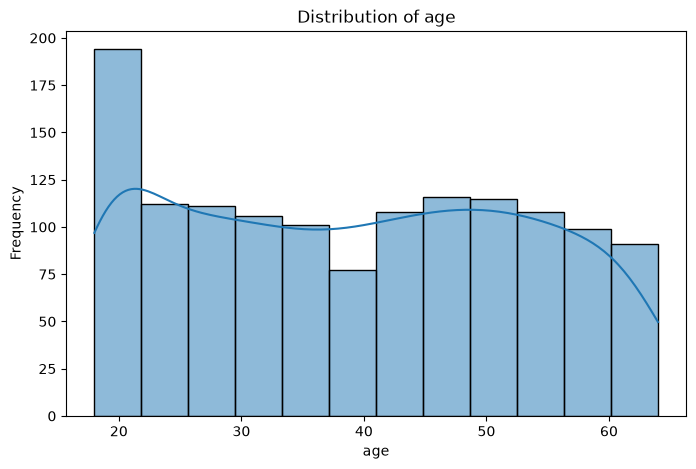

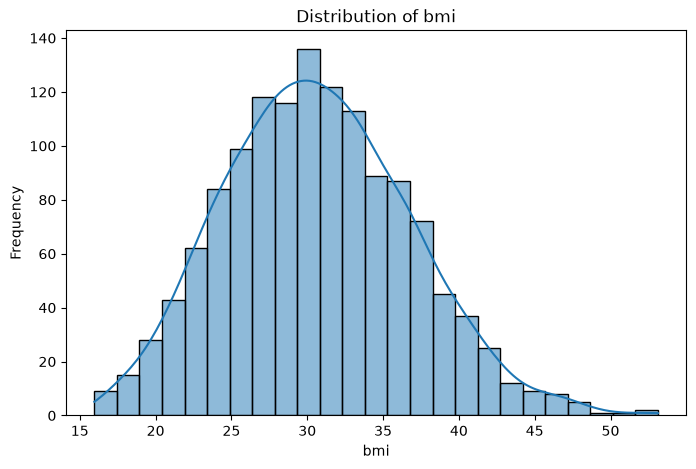

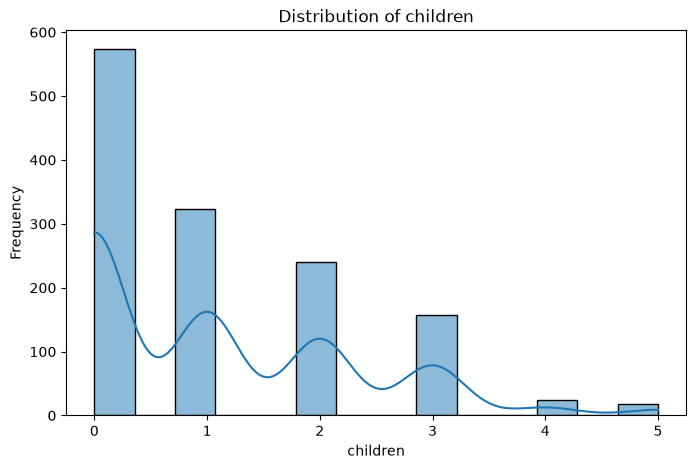

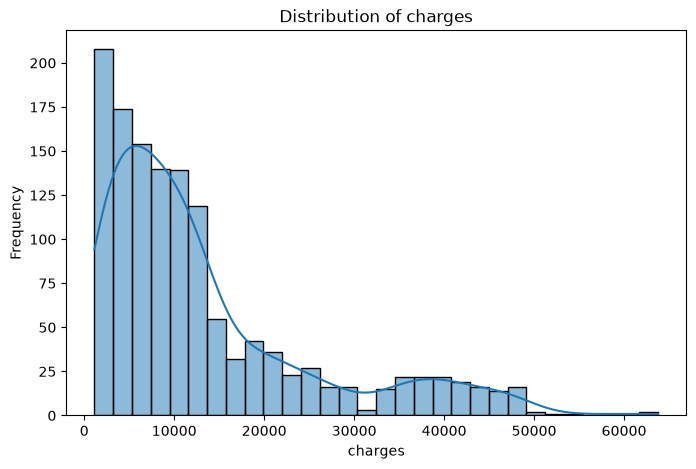

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution plots
for column in numerical_columns:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

## Bivariate Scatter plot

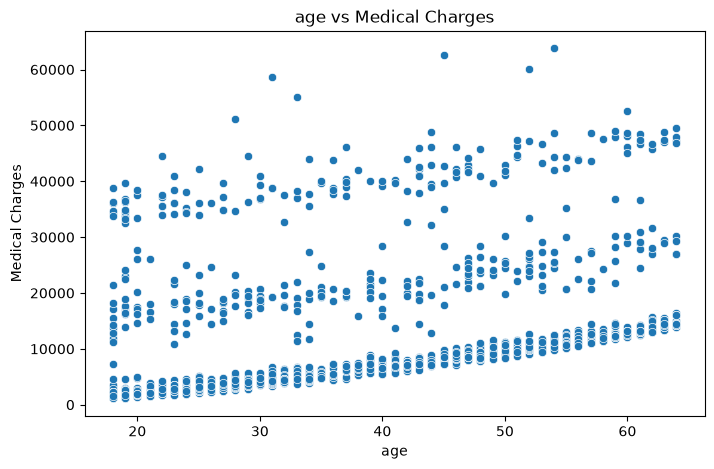

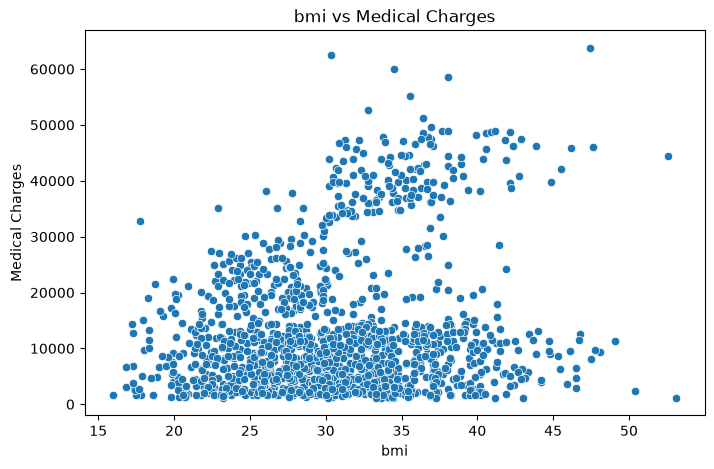

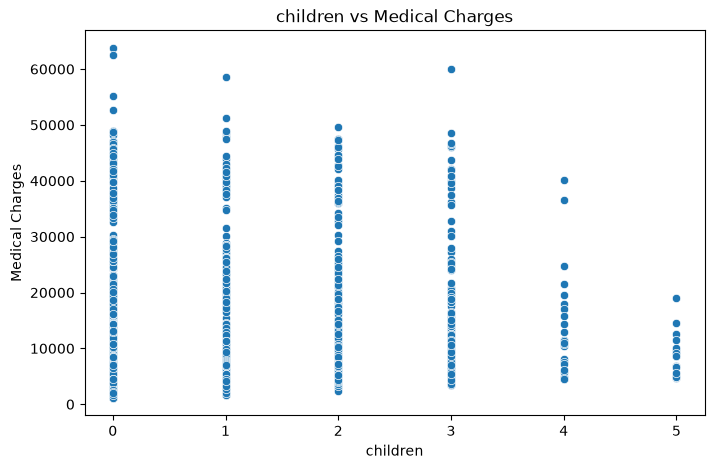

In [5]:
# Scatter plots: numerical predictors vs medical charges

predictors = ["age", "bmi", "children"]

for column in predictors:
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=column,
        y="charges"
    )

    plt.title(f"{column} vs Medical Charges")
    plt.xlabel(column)
    plt.ylabel("Medical Charges")
    plt.show()

## Correlation Matrix

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


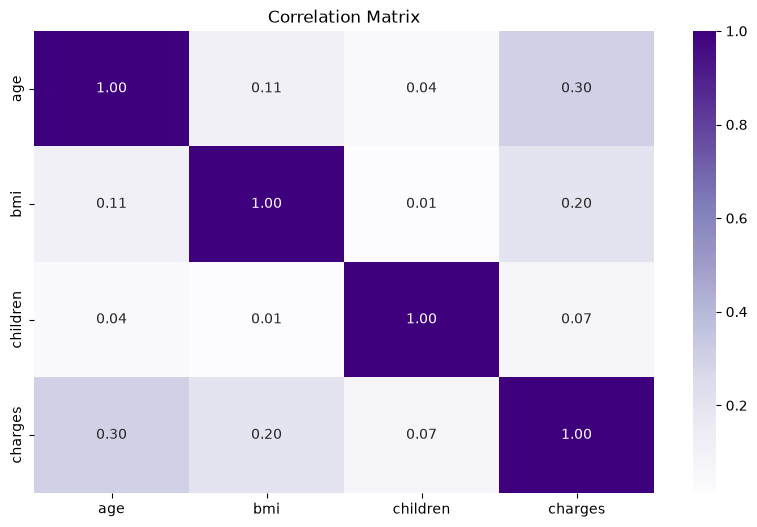

In [6]:
# Correlation matrix

correlation_matrix = df[numerical_columns].corr()

print(correlation_matrix)

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Hypothesis Test 1 — Smokers vs Non-smoker

In [7]:
from scipy import stats

# Separate charges into two groups
smokers = df[df["smoker"] == "yes"]["charges"]
non_smokers = df[df["smoker"] == "no"]["charges"]

print("Number of smokers:", len(smokers))
print("Number of non-smokers:", len(non_smokers))

print("\nMean charges:")
print("Smokers:", smokers.mean())
print("Non-smokers:", non_smokers.mean())

Number of smokers: 274
Number of non-smokers: 1064

Mean charges:
Smokers: 32050.23183153284
Non-smokers: 8434.268297856204


### Shapiro-Wilk normality tests

In [8]:
shapiro_smokers = stats.shapiro(smokers)
shapiro_non_smokers = stats.shapiro(non_smokers)

print("Shapiro-Wilk Test — Smokers")
print("Statistic:", shapiro_smokers.statistic)
print("p-value:", shapiro_smokers.pvalue)

print("\nShapiro-Wilk Test — Non-smokers")
print("Statistic:", shapiro_non_smokers.statistic)
print("p-value:", shapiro_non_smokers.pvalue)

Shapiro-Wilk Test — Smokers
Statistic: 0.9395519386965634
p-value: 3.6249900590074145e-09

Shapiro-Wilk Test — Non-smokers
Statistic: 0.8728637657160003
p-value: 1.4459006706130622e-28


### Levene's test for equality of variances

In [9]:
levene_test = stats.levene(smokers, non_smokers)

print("Levene's Test")
print("Statistic:", levene_test.statistic)
print("p-value:", levene_test.pvalue)

Levene's Test
Statistic: 332.6135162726081
p-value: 1.5593284881803726e-66


### Mann-Whitney U test

In [10]:
mann_whitney = stats.mannwhitneyu(
    smokers,
    non_smokers,
    alternative="two-sided"
)

print("Mann-Whitney U Test")
print("U statistic:", mann_whitney.statistic)
print("p-value:", mann_whitney.pvalue)

Mann-Whitney U Test
U statistic: 284133.0
p-value: 5.270233444503571e-130


## Hypothesis Test 2 — One-Way ANOVA.

In [11]:
# Charges by region

region_summary = df.groupby("region")["charges"].agg(
    ["count", "mean", "median", "std"]
)

print(region_summary)

           count          mean        median           std
region                                                    
northeast    324  13406.384516  10057.652025  11255.803066
northwest    325  12417.575374   8965.795750  11072.276928
southeast    364  14735.411438   9294.131950  13971.098589
southwest    325  12346.937377   8798.593000  11557.179101


In [12]:
# Create groups for ANOVA

northeast = df[df["region"] == "northeast"]["charges"]
northwest = df[df["region"] == "northwest"]["charges"]
southeast = df[df["region"] == "southeast"]["charges"]
southwest = df[df["region"] == "southwest"]["charges"]

In [13]:
# One-Way ANOVA

anova_result = stats.f_oneway(
    northeast,
    northwest,
    southeast,
    southwest
)

print("One-Way ANOVA")
print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

One-Way ANOVA
F-statistic: 2.96962669358912
p-value: 0.0308933560705201


In [14]:
region_summary = df.groupby("region")["charges"].agg(
    ["count", "mean", "median", "std"]
)

print(region_summary)

           count          mean        median           std
region                                                    
northeast    324  13406.384516  10057.652025  11255.803066
northwest    325  12417.575374   8965.795750  11072.276928
southeast    364  14735.411438   9294.131950  13971.098589
southwest    325  12346.937377   8798.593000  11557.179101


In [15]:
anova_result = stats.f_oneway(
    northeast,
    northwest,
    southeast,
    southwest
)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 2.96962669358912
p-value: 0.0308933560705201


## Part 2: Statistical Modeling & Diagnostic Checks

## Model Formulation

In [16]:
import statsmodels.api as sm

# Select predictors
X = pd.get_dummies(
    df[["age", "bmi", "children", "sex", "smoker", "region"]],
    drop_first=True
)

# Convert dummy variables to integers
X = X.astype(int)

# Target
y = df["charges"]

# Add intercept
X = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Display results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.7
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:42:34   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.174e+04    975.287  

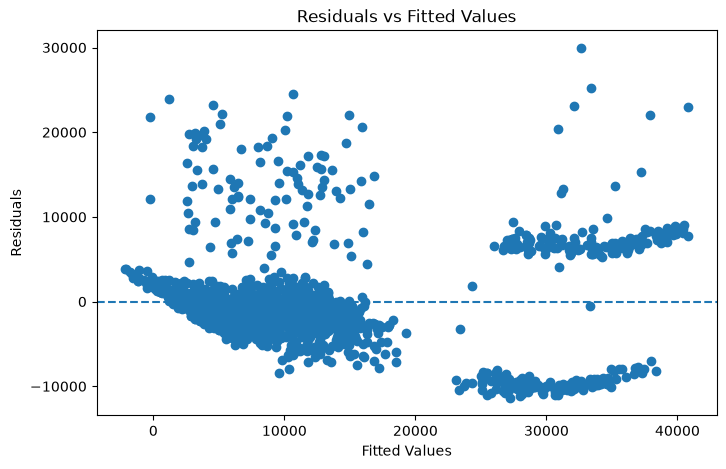

In [17]:
model = sm.OLS(y, X).fit()
import matplotlib.pyplot as plt

# Get predicted values
fitted_values = model.fittedvalues

# Get residuals
residuals = model.resid

# Residuals vs Fitted plot
plt.figure(figsize=(8, 5))

plt.scatter(fitted_values, residuals)

# Horizontal line at residual = 0
plt.axhline(y=0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

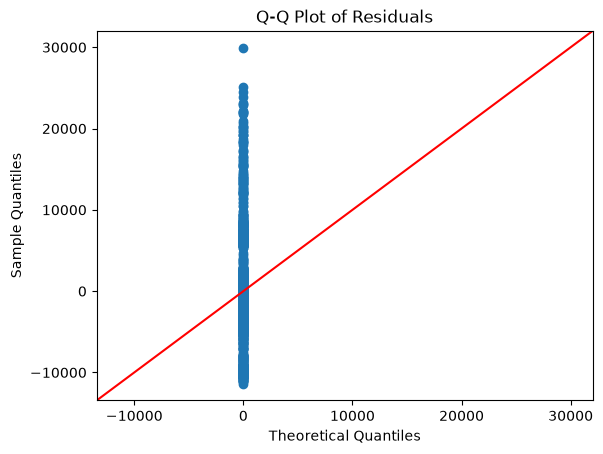

In [18]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Q-Q plot of residuals
sm.qqplot(residuals, line="45")

plt.title("Q-Q Plot of Residuals")
plt.show()

In [19]:
from statsmodels.stats.diagnostic import het_breuschpagan

residuals = model.resid

bp_test = het_breuschpagan(residuals, model.model.exog)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

Breusch-Pagan Test
LM Statistic: 121.96483418039045
LM p-value: 1.3021759885032354e-22
F Statistic: 16.661860320923484
F p-value: 1.0206175515135185e-23


# OLS Summary 

In [20]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.7
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:42:34   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.174e+04    975.287  

## Check Multicollinearity using VIF

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Remove the constant before calculating VIF
X_vif = X.drop(columns=["const"])

vif_data = pd.DataFrame()

vif_data["Variable"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data)

           Variable       VIF
0               age  1.016636
1               bmi  1.107868
2          children  1.003971
3          sex_male  1.008930
4        smoker_yes  1.012149
5  region_northwest  1.518821
6  region_southeast  1.653430
7  region_southwest  1.529859


## Check Homoscedasticity

In [22]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan test
bp_test = het_breuschpagan(residuals, X)

labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value"
]

for label, value in zip(labels, bp_test):
    print(f"{label}: {value}")

LM Statistic: 121.96483418039045
LM-Test p-value: 1.3021759885032354e-22
F-Statistic: 16.661860320923484
F-Test p-value: 1.0206175515135185e-23


In [23]:
# OLS model with heteroscedasticity-robust standard errors
robust_model = model.get_robustcov_results(cov_type="HC3")

print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     298.4
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          2.47e-290
Time:                        11:42:34   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.174e+04   1035.319  

## Final regression interpretation

In [24]:
# Create a clean regression results table

results_table = pd.DataFrame({
    "Coefficient": robust_model.params,
    "Std Error (HC3)": robust_model.bse,
    "P-value": robust_model.pvalues,
    "CI Lower": robust_model.conf_int()[:, 0],
    "CI Upper": robust_model.conf_int()[:, 1]
})

print(results_table)

    Coefficient  Std Error (HC3)        P-value      CI Lower      CI Upper
0 -11741.432494      1035.319087   1.605197e-28 -13772.470323  -9710.394665
1    256.976935        11.967837   4.848865e-88    233.499023    280.454847
2    337.988864        31.820884   2.376075e-25    275.564226    400.413502
3    478.225974       131.010805   2.721149e-04    221.215451    735.236498
4   -132.453026       334.977871   6.926051e-01   -789.596062    524.690010
5  23859.788592       578.172797  2.736481e-240  22725.557768  24994.019416
6   -346.433637       486.852467   4.768508e-01  -1301.516750    608.649477
7  -1042.406732       503.352871   3.855834e-02  -2029.859524    -54.953941
8   -969.556124       463.337152   3.657863e-02  -1878.508054    -60.604194
